In [1]:
print("Hello world")

Hello world


In [17]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.6/8.1 MB 5.6 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 5.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.1 MB 5.8 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.1 MB 6.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.5 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.6 MB 10.1 MB/s eta 0:00:04
   ---- ----------------------------------- 3.7/36.6 MB 9.1 MB/s eta 0:00:04
   ------ --------------------------------- 5.5/36.6 MB 9.1 MB/s eta 0:00:04
   -------- ------------------------------- 7.9/36.6 MB 9.7 MB/s eta 0:00:03
   ---------- ---------

In [3]:
from sklearn.datasets import load_iris

iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [7]:
X = iris.data
Y = iris.target

In [19]:
X = torch.tensor(X,dtype = torch.float32)
Y = torch.tensor(Y,dtype = torch.long)

C:\Users\srish\AppData\Local\Temp\ipykernel_27120\3636083646.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X,dtype = torch.float32)
C:\Users\srish\AppData\Local\Temp\ipykernel_27120\3636083646.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y,dtype = torch.long)


In [53]:
lossi = []
stepi = []

In [54]:
W1 = torch.randn((4,8),requires_grad=True)
b1 = torch.randn(8,requires_grad=True)
W2 = torch.randn((8,8),requires_grad=True)
b2 = torch.randn(8,requires_grad=True)
W3 = torch.randn((8,3),requires_grad=True)
b3 = torch.randn(3,requires_grad=True)
parameters = [W1, b1, W2,b2, W3,b3]

In [55]:
for i in range(20000):
    
    h1 = torch.tanh(X @ W1 + b1)
    h2 = torch.tanh(h1 @ W2 + b2)
    logits = h2 @ W3 + b3
    loss = F.cross_entropy(logits, Y)
    for parameter in parameters:
        parameter.grad = None
        
    loss.backward()
    
    lr = 0.01
    
    for p in parameters:
        p.data +=  -lr * p.grad
        
    stepi.append(i)
    lossi.append(loss.item())
    

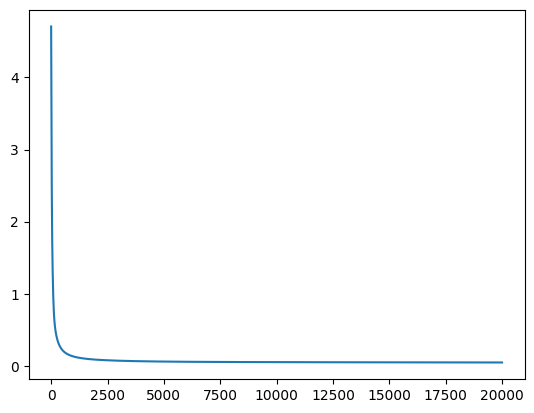

In [56]:
plt.plot(stepi,lossi)

In [43]:
pred = logits.argmax(1)
pred

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

In [44]:
acc = (pred == Y).float().mean()

print(acc)

tensor(0.9867)


In [62]:
x = torch.tensor([[7.2, 3.6, 6.1, 2.5]], dtype=torch.float32)
h1 = torch.tanh(x @ W1 + b1)
h2 = torch.tanh(h1 @ W2 + b2)
logits = h2 @ W3 + b3
pred = logits.argmax(1).item()
flowers = ['setosa', 'versicolor', 'virginica']

print("Predicted flower:", flowers[pred])

Predicted flower: virginica
